# Prédiction consommation totale d'énergie (SiteEUIWN(kBtu/sf))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.metrics import *
from sklearn.preprocessing import LabelBinarizer, RobustScaler, OneHotEncoder

# Pour les différents modèles
from sklearn import dummy
from sklearn import linear_model
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, BayesianRidge, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, make_column_selector

# Feature selection et feature importance
from sklearn.feature_selection import SelectFromModel
import shap

In [3]:
data = pd.read_csv('data_clean.csv', index_col=0)

In [4]:
data

,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,SiteEUIWN(kBtu/sf),...,Residential Care Facility,Restaurant,Retail Store,Self-Storage Facility,Senior Care Community,Social/Meeting Hall,Strip Mall,Supermarket/Grocery Store,Urgent Care/Clinic/Other Outpatient,Worship Facility
0,Hotel,7,DOWNTOWN,1.0,12,88434,0,88434,60.0,84.300003,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Hotel,7,DOWNTOWN,1.0,11,103566,15064,88502,61.0,97.900002,...,0.0,0.044629,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Hotel,7,DOWNTOWN,1.0,41,956110,196718,759392,43.0,97.699997,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Hotel,7,DOWNTOWN,1.0,10,61320,0,61320,56.0,113.300003,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Hotel,7,DOWNTOWN,1.0,18,175580,62000,113580,75.0,118.699997,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,Mixed Use Property,3,CENTRAL,1.0,1,20050,0,20050,NaN,99.400002,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1313,Other,1,DELRIDGE,1.0,1,18261,0,18261,NaN,56.200001,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1314,Other,2,DOWNTOWN,1.0,1,16000,0,16000,NaN,65.900002,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1315,Mixed Use Property,1,GREATER DUWAMISH,1.0,1,14101,0,14101,NaN,55.500000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
data.dtypes.value_counts()

float64    60
int64       6
object      2
dtype: int64

In [6]:
data.columns

Index(['PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore',
       'SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity', 'SteamUse(ratio)',
       'Electricity(ratio)', 'NaturalGas(ratio)', 'Age', 'Adult Education',
       'Automobile Dealership', 'Bank Branch', 'College/University',
       'Courthouse', 'Data Center', 'Distribution Center', 'Financial Office',
       'Fire Station', 'Fitness Center/Health Club/Gym',
       'Hospital (General Medical & Surgical)', 'Hotel', 'K-12 School',
       'Laboratory', 'Library', 'Lifestyle Center',
       'Manufacturing/Industrial Plant', 'Medical Office', 'Movie Theater',
       'Multifamily Housing', 'Museum', 'Non-Refrigerated Warehouse', 'Office',
       'Other', 'Other - Education', 'Other - Entertainment/Public Assembly',
       'Other - Lodging/Residential', 'Other - Mall',
       'Other - Public Se

In [7]:
X = data.drop(['GHGEmissionsIntensity', 'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)'], axis=1)
y = data['SiteEUIWN(kBtu/sf)']

In [8]:
# Column_transformer
numerical_features = make_column_selector(dtype_include=np.number)
categorical_features = make_column_selector(dtype_exclude=np.number)

# Créer les pipelines de transfo des features num et cat
numerical_pipeline = make_pipeline(RobustScaler())
categorical_pipeline = make_pipeline(OneHotEncoder())

# Assembler les 2 pipelines dans le column transformer
preprocessor = make_column_transformer((numerical_pipeline, numerical_features),
                       (categorical_pipeline, categorical_features))

In [9]:
X.shape

(1317, 65)

In [10]:
# Préparation du dataframe contenant les scores des différents modèles
columns = ['Modèle', 'Paramètres', 'R²_train', 'R²_test', 'MAE', 'RMSE', 'Median_absolute_error', 'Training_time']
df_score = pd.DataFrame(columns = columns)

In [11]:
def test_model(X, y, preprocessor, model, imp=None, df_score=df_score):
    
    taille = df_score.shape[0]
    
    # Découper en train/test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # Fit avec le train set
    pipeline = make_pipeline(preprocessor, model)
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
        
    # Predict
    y_pred = pipeline.predict(X_test)
    
    df_score.loc[taille + 1] = [model,
                                model.get_params(),
                                pipeline.score(X_train, y_train),
                                pipeline.score(X_test, y_test),
                                mean_absolute_error(y_test, y_pred),
                                np.sqrt(mean_squared_error(y_test, y_pred)),
                                median_absolute_error(y_test, y_pred),
                                training_time]
    
    # Affiche le diagramme des valeurs prédites / valeurs réelles
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.text((y_test.max()/2), y_test.max(), 'R² = %.5f' % (pipeline.score(X_test, y_test)))
    plt.xlabel('y')
    plt.ylabel('y prédit')
    plt.title(model)

    return df_score

In [12]:
#Liste des modèles à tester
models = [linear_model.LinearRegression(),
          linear_model.Ridge(),
          linear_model.Lasso(),
          ElasticNet(),
          SGDRegressor(),
          RandomForestRegressor(),
          DecisionTreeRegressor(),
          XGBRegressor(),
          KNeighborsRegressor(),
          dummy.DummyRegressor(strategy='mean')]

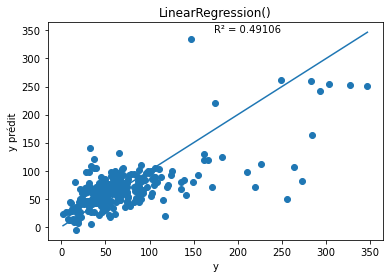

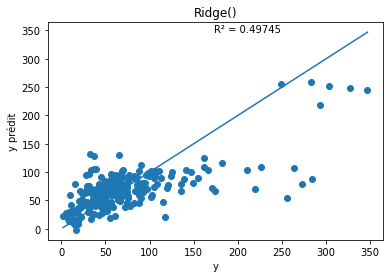

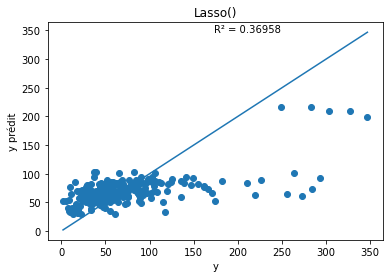

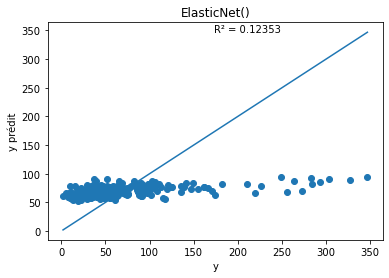

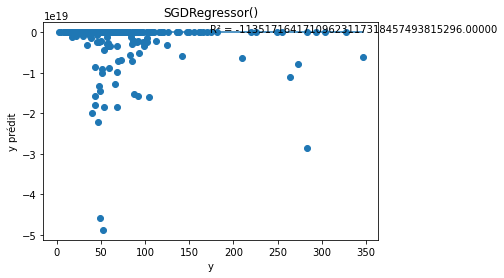

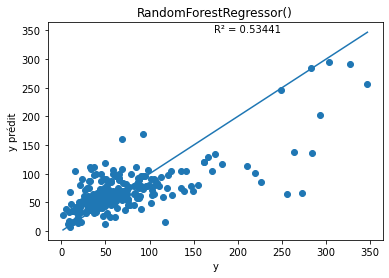

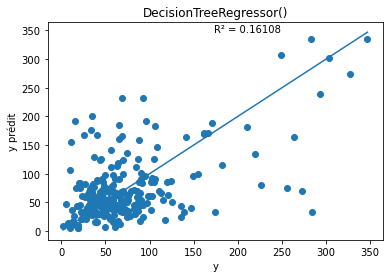

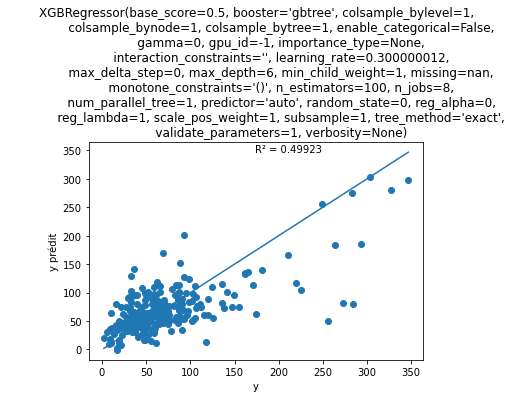

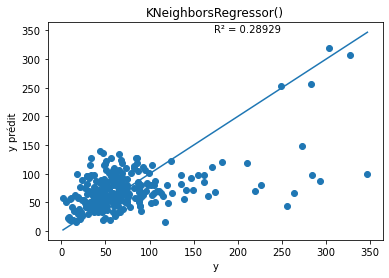

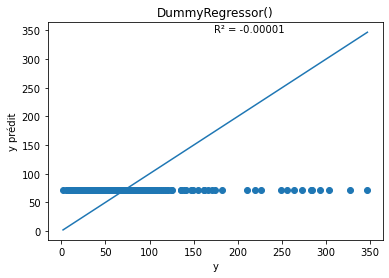

In [13]:
for mod in models:
    test_model(X, y, preprocessor, mod)

In [14]:
df_score.sort_values(by='R²_test', ascending=False)

,Modèle,Paramètres,R²_train,R²_test,MAE,RMSE,Median_absolute_error,Training_time
6,"(DecisionTreeRegressor(max_features='auto', ra...","{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",9.341865e-01,5.344067e-01,2.598058e+01,3.906808e+01,1.837850e+01,1.382880
8,"XGBRegressor(base_score=0.5, booster='gbtree',...","{'objective': 'reg:squarederror', 'base_score'...",9.751449e-01,4.992339e-01,2.727482e+01,4.051689e+01,1.844176e+01,0.329626
2,Ridge(),"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",5.767212e-01,4.974490e-01,2.664998e+01,4.058904e+01,1.776777e+01,0.108624
1,LinearRegression(),"{'copy_X': True, 'fit_intercept': True, 'n_job...",5.924594e-01,4.910581e-01,2.695269e+01,4.084631e+01,1.832241e+01,0.573246
3,Lasso(),"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",4.009464e-01,3.695835e-01,2.964682e+01,4.546032e+01,2.084606e+01,0.104974
9,KNeighborsRegressor(),"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",5.465524e-01,2.892893e-01,3.273349e+01,4.826865e+01,2.300000e+01,0.034230
7,DecisionTreeRegressor(),"{'ccp_alpha': 0.0, 'criterion': 'mse', 'max_de...",1.000000e+00,1.610793e-01,3.511705e+01,5.244199e+01,2.215000e+01,0.057009
4,ElasticNet(),"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",1.316381e-01,1.235336e-01,3.461462e+01,5.360266e+01,2.478405e+01,0.031228
10,DummyRegressor(),"{'constant': None, 'quantile': None, 'strategy...",0.000000e+00,-7.195418e-06,3.758622e+01,5.725590e+01,2.598846e+01,0.030287
5,SGDRegressor(),"{'alpha': 0.0001, 'average': False, 'early_sto...",-1.874851e+34,-1.135172e+34,1.911902e+18,6.100276e+18,3.643985e+10,0.062204


In [15]:
# Pour chaque modèle, recherche des meilleurs hyperparamètres

In [16]:
# Dataframe des scores avec GridSearchCV
columns = ['Modèle', 'Meilleurs paramètres', 'R²_train', 'R²_test', 'MAE', 'RMSE', 'Median absolute error', 'Training_time']
df_score_CV = pd.DataFrame(columns = columns)

In [17]:
# Créer une classe pour associer modèles et param_grid
class models_cv:
    def __init__(self, model, param_grid):
        self.model = model
        self.param_grid = param_grid

In [18]:
# Instancier tous les modèles
linear_reg = models_cv(model = linear_model.LinearRegression(),
                       param_grid = {'fit_intercept': [True, False]}
                      )
ridge = models_cv(model = linear_model.Ridge(max_iter=12000),
                  param_grid = {'alpha': [1.0, 0.8, 0.6, 0.4, 0.2, 0.1]}
                 )
lasso = models_cv(model = linear_model.Lasso(max_iter=12000),
                  param_grid = {'alpha': [1.0, 0.8, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01]}
                 )
elastic_net = models_cv(model = ElasticNet(max_iter=12000),
                        param_grid = {'alpha': [1.0, 0.5, 0.1, 0.05],
                                      'l1_ratio' : [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]}
                       )
SGDreg = models_cv(model = SGDRegressor(),
                   param_grid = {'alpha': [1.0, 0.8, 0.5, 0.2, 0.1, 0.05, 0.01, 0.001, 0.0001]}
                  )
random_forest_reg = models_cv(model = RandomForestRegressor(),
                              param_grid = {'n_estimators': [50, 100, 200, 300]}
                             )
decision_tree_reg = models_cv(model = DecisionTreeRegressor(),
                              param_grid = {'criterion': ["mse", "friedman_mse", "mae", "poisson"]}
                             )
XGB_reg = models_cv(model = XGBRegressor(),
                    param_grid = {'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5]}
                   )
KN_reg = models_cv(model = KNeighborsRegressor(),
                   param_grid = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8]}
                  )

In [19]:
# Liste des modèles
model_cv_list = [linear_reg, ridge, lasso, elastic_net, SGDreg, random_forest_reg, decision_tree_reg, XGB_reg, KN_reg]

In [20]:
#Définir une fonction qui retourne les scores optimisés avec GridSearchCV

def scoreCV(X, y, preprocessor, model_cv, df_score_CV):
    taille = df_score_CV.shape[0]
    
    # Découper en train/test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # Recherche des meilleurs paramètres
    grid = GridSearchCV(model_cv.model,
                        model_cv.param_grid,
                        cv=5,
                        return_train_score=True,
                        refit=True,
                       scoring='r2')
    
    pipeline = make_pipeline(preprocessor, grid)

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
        
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Enregistrer les meilleurs paramètres du modèle
    model_cv.best_params = grid.best_params_
    
    # Remplir le tableau des résultats
    df_score_CV.loc[taille + 1] = [model_cv.model,
                                grid.best_params_,
                                pipeline.score(X_train, y_train),
                                pipeline.score(X_test, y_test),
                                mean_absolute_error(y_test, y_pred),
                                np.sqrt(mean_squared_error(y_test, y_pred)),
                                median_absolute_error(y_test, y_pred),
                                training_time]
    
    return df_score_CV

In [21]:
for mod in model_cv_list:
    scoreCV(X, y, preprocessor, mod, df_score_CV)

LinearRegression()
Ridge(max_iter=12000)
Lasso(max_iter=12000)


Objective did not converge. You might want to increase the number of iterations. Duality gap: 603349.2149042521, tolerance: 287.1875898388424


ElasticNet(max_iter=12000)
SGDRegressor()
RandomForestRegressor()
DecisionTreeRegressor()
XGBRegressor(base_score=None, booster=None, colsample_bylevel=None,
             colsample_bynode=None, colsample_bytree=None,
             enable_categorical=False, gamma=None, gpu_id=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_delta_step=None, max_depth=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, reg_alpha=None, reg_lambda=None,
             scale_pos_weight=None, subsample=None, tree_method=None,
             validate_parameters=None, verbosity=None)
KNeighborsRegressor()


In [22]:
df_score_CV.sort_values(by='R²_test', ascending=False)

,Modèle,Meilleurs paramètres,R²_train,R²_test,MAE,RMSE,Median absolute error,Training_time
6,RandomForestRegressor(),{'n_estimators': 200},9.360554e-01,5.401201e-01,2.568756e+01,3.882763e+01,1.758750e+01,32.919643
8,"XGBRegressor(base_score=None, booster=None, co...",{'learning_rate': 0.1},8.710887e-01,5.267326e-01,2.590135e+01,3.938873e+01,1.777943e+01,4.669840
2,Ridge(max_iter=12000),{'alpha': 1.0},5.767212e-01,4.974490e-01,2.664998e+01,4.058904e+01,1.776777e+01,0.165784
1,LinearRegression(),{'fit_intercept': True},5.924594e-01,4.910581e-01,2.695269e+01,4.084631e+01,1.832241e+01,0.130493
3,Lasso(max_iter=12000),{'alpha': 0.1},5.587431e-01,4.827757e-01,2.666807e+01,4.117732e+01,1.698032e+01,5.277511
4,ElasticNet(max_iter=12000),"{'alpha': 0.05, 'l1_ratio': 0.9}",5.413695e-01,4.695425e-01,2.723742e+01,4.170076e+01,1.788796e+01,7.415099
9,KNeighborsRegressor(),{'n_neighbors': 8},4.842122e-01,3.301738e-01,3.119058e+01,4.685973e+01,2.340000e+01,1.020885
7,DecisionTreeRegressor(),{'criterion': 'mae'},1.000000e+00,-8.536985e-02,3.941364e+01,5.964960e+01,2.265000e+01,2.435075
5,SGDRegressor(),{'alpha': 0.01},-7.210294e+30,-4.365639e+30,3.749377e+16,1.196307e+17,3.808381e+10,0.472161


## Feature selection

In [23]:
# Pour la feature selection avec SelecteFromModel, suppression du KNN car ni coef ni importance
model_cv_list.remove(KN_reg)

In [24]:
# Avec le selector
def test_model_selector(X, y, preprocessor, mod, imp=None, df_score=df_score):
    
    taille = df_score.shape[0]
    # Récupération des meilleurs hyperparamètres du model
    modele = mod.model
    modele.set_params(**mod.best_params)
    
    # Découper en train/test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    
    # Ajout du selector
    selector = SelectFromModel(modele)
    
    # Fit avec le train set
    pipeline = make_pipeline(preprocessor, selector, modele)
    pipeline.fit(X_train, y_train)
        
    # Predict
    y_pred = pipeline.predict(X_test)
    
    df_score.loc[taille + 1] = [modele,
                                modele.get_params(),
                                pipeline.score(X_train, y_train),
                                pipeline.score(X_test, y_test),
                                mean_absolute_error(y_test, y_pred),
                                np.sqrt(mean_squared_error(y_test, y_pred)),
                                median_absolute_error(y_test, y_pred)]
    
    # Affiche le diagramme des valeurs prédites / valeurs réelles
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.xlabel('y')
    plt.ylabel('y prédit')
    plt.title(modele)

    return df_score

In [25]:
# Préparation du dataframe contenant les scores des différents modèles
columns = ['Modèle', 'Paramètres', 'R²_train', 'R²_test', 'MAE', 'RMSE', 'Median absolute error']
df_score_feature_selection = pd.DataFrame(columns = columns)

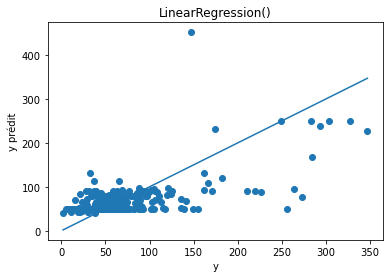

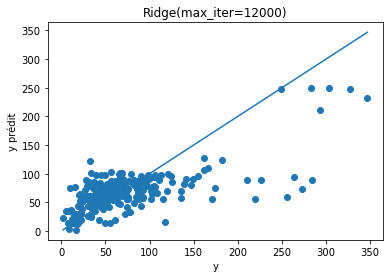

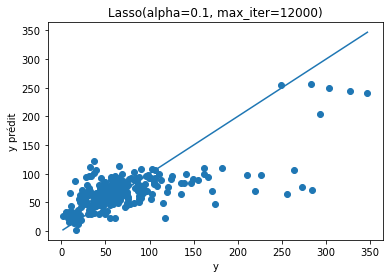

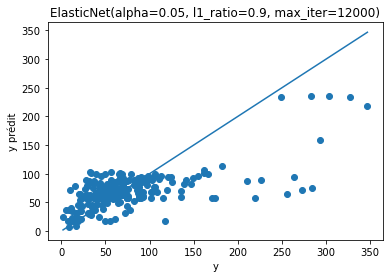

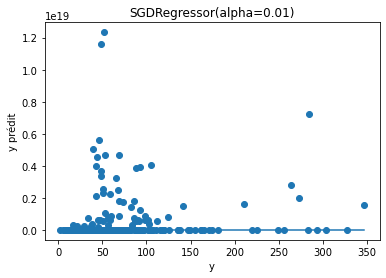

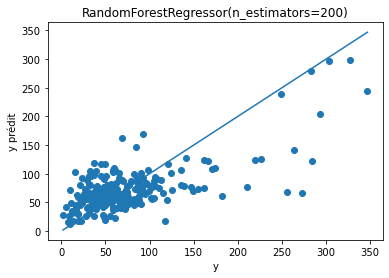

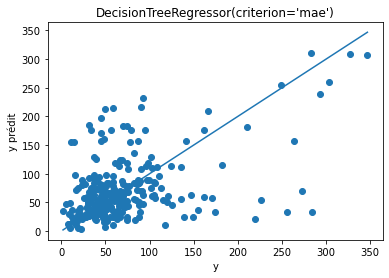

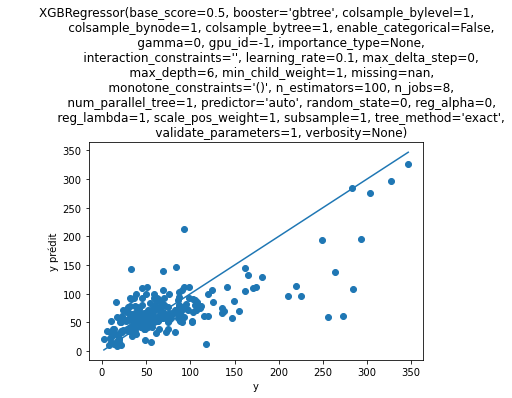

In [26]:
for mod in model_cv_list:
    test_model_selector(X, y, preprocessor, mod, imp=None, df_score=df_score_feature_selection)

In [27]:
df_score_feature_selection.sort_values(by='R²_test', ascending=False)

,Modèle,Paramètres,R²_train,R²_test,MAE,RMSE,Median absolute error
8,"XGBRegressor(base_score=0.5, booster='gbtree',...","{'objective': 'reg:squarederror', 'base_score'...",8.320294e-01,5.201019e-01,2.610644e+01,3.966370e+01,1.608912e+01
6,"(DecisionTreeRegressor(max_features='auto', ra...","{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",9.313930e-01,4.913667e-01,2.783635e+01,4.083392e+01,1.938800e+01
3,"Lasso(alpha=0.1, max_iter=12000)","{'alpha': 0.1, 'copy_X': True, 'fit_intercept'...",5.587440e-01,4.827990e-01,2.666548e+01,4.117640e+01,1.699219e+01
2,Ridge(max_iter=12000),"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",5.436987e-01,4.681989e-01,2.742287e+01,4.175354e+01,1.949991e+01
4,"ElasticNet(alpha=0.05, l1_ratio=0.9, max_iter=...","{'alpha': 0.05, 'copy_X': True, 'fit_intercept...",5.130615e-01,4.363097e-01,2.807650e+01,4.298718e+01,1.958313e+01
1,LinearRegression(),"{'copy_X': True, 'fit_intercept': True, 'n_job...",5.033132e-01,3.889183e-01,2.886607e+01,4.475776e+01,1.969196e+01
7,DecisionTreeRegressor(criterion='mae'),"{'ccp_alpha': 0.0, 'criterion': 'mae', 'max_de...",1.000000e+00,1.377122e-02,3.709811e+01,5.686009e+01,2.210000e+01
5,SGDRegressor(alpha=0.01),"{'alpha': 0.01, 'average': False, 'early_stopp...",-1.199996e+33,-7.265653e+32,4.836957e+17,1.543320e+18,6.425356e+09


In [28]:
# Pas d'amélioration avec cette feature selection

In [29]:
# Optimisation des hyperparamètres pour le modèle ridge

In [30]:
ridge = models_cv(model = linear_model.Ridge(max_iter=12000),
                  param_grid = {'alpha': [0.5, 0.9, 1.0, 3.0, 5.0],
                               'solver' : ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
                               }
                 )

In [31]:
scoreCV(X, y, preprocessor, ridge, df_score_CV)

Ridge(max_iter=12000)


,Modèle,Meilleurs paramètres,R²_train,R²_test,MAE,RMSE,Median absolute error,Training_time
1,LinearRegression(),{'fit_intercept': True},5.924594e-01,4.910581e-01,2.695269e+01,4.084631e+01,1.832241e+01,0.130493
2,Ridge(max_iter=12000),{'alpha': 1.0},5.767212e-01,4.974490e-01,2.664998e+01,4.058904e+01,1.776777e+01,0.165784
3,"Lasso(alpha=0.1, max_iter=12000)",{'alpha': 0.1},5.587431e-01,4.827757e-01,2.666807e+01,4.117732e+01,1.698032e+01,5.277511
4,"ElasticNet(alpha=0.05, l1_ratio=0.9, max_iter=...","{'alpha': 0.05, 'l1_ratio': 0.9}",5.413695e-01,4.695425e-01,2.723742e+01,4.170076e+01,1.788796e+01,7.415099
5,SGDRegressor(alpha=0.01),{'alpha': 0.01},-7.210294e+30,-4.365639e+30,3.749377e+16,1.196307e+17,3.808381e+10,0.472161
6,"(DecisionTreeRegressor(max_features='auto', ra...",{'n_estimators': 200},9.360554e-01,5.401201e-01,2.568756e+01,3.882763e+01,1.758750e+01,32.919643
7,DecisionTreeRegressor(criterion='mae'),{'criterion': 'mae'},1.000000e+00,-8.536985e-02,3.941364e+01,5.964960e+01,2.265000e+01,2.435075
8,"XGBRegressor(base_score=0.5, booster='gbtree',...",{'learning_rate': 0.1},8.710887e-01,5.267326e-01,2.590135e+01,3.938873e+01,1.777943e+01,4.669840
9,KNeighborsRegressor(),{'n_neighbors': 8},4.842122e-01,3.301738e-01,3.119058e+01,4.685973e+01,2.340000e+01,1.020885
10,Ridge(max_iter=12000),"{'alpha': 1.0, 'solver': 'svd'}",5.767212e-01,4.974490e-01,2.664998e+01,4.058904e+01,1.776777e+01,1.438167


In [32]:
selected_model = linear_model.Ridge(alpha = 1.0, solver = 'svd')

In [33]:
shap.initjs()

In [34]:
# Découper en train/test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

 R² =  0.49744903606747515


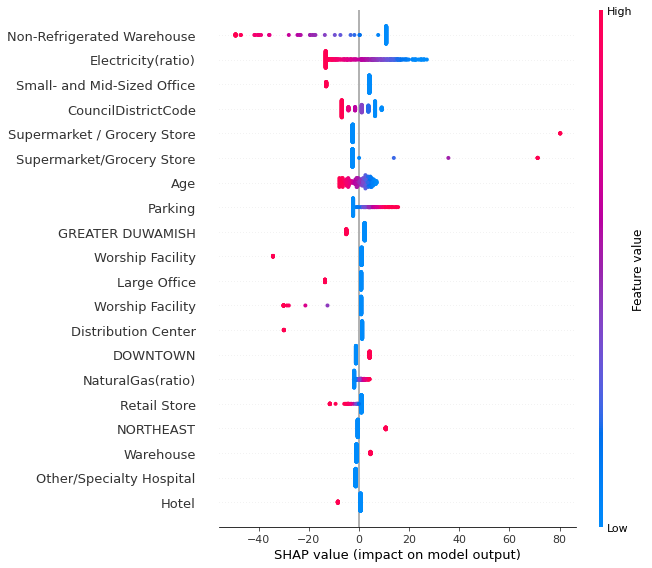

In [35]:
# Fit avec le train set
pipeline = make_pipeline(preprocessor, selected_model)
pipeline.fit(X_train, y_train)

# SHAP
lin_reg_explainer1 = shap.LinearExplainer(selected_model, preprocessor.transform(X_train))
        
# Predict
y_pred = pipeline.predict(X_test)

print(' R² = ', pipeline.score(X_test, y_test))

plt.figure()
shap.summary_plot(lin_reg_explainer1.shap_values(preprocessor.transform(X_test)),
                  features = preprocessor.transform(X_test),
                # Récupérer les noms de variables après preprocess
                  feature_names = np.concatenate((preprocessor.transformers_[0][2], 
                                                preprocessor.transformers_[1][1][0].categories_[0], 
                                                 preprocessor.transformers_[1][1][0].categories_[1]), 
                                                 axis=None)
                 )

In [36]:
# Avec le energy star score

In [37]:
# Charger le dataframe avec uniquement les bâtiments pour lesquels le score est connu
data_energy_star_score = pd.read_csv('df_energy_star_score.csv', index_col=0)

In [38]:
X = data_energy_star_score.drop(axis=1, labels=['SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity'])
y = data_energy_star_score['SiteEUIWN(kBtu/sf)']

In [39]:
# Découper en train/test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

 R² =  0.8434188548687855


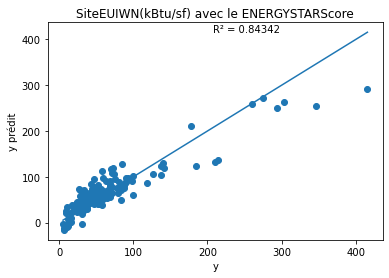

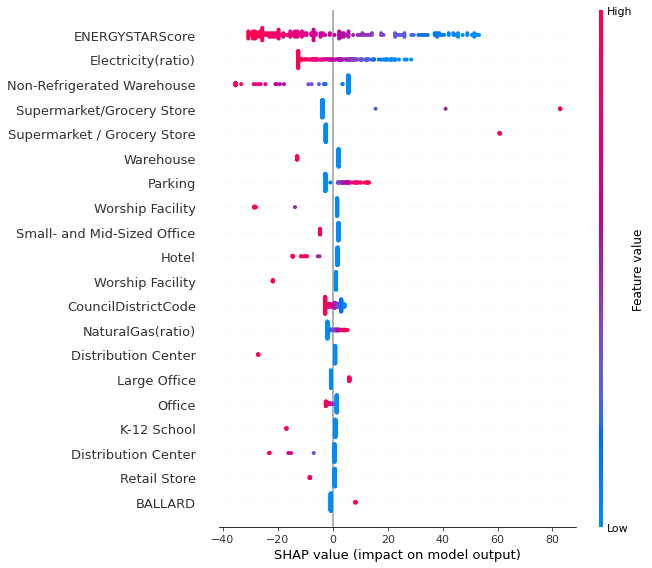

In [40]:
# Fit avec le train set
pipeline = make_pipeline(preprocessor, selected_model)
pipeline.fit(X_train, y_train)

# SHAP
lin_reg_explainer1 = shap.LinearExplainer(selected_model, preprocessor.transform(X_train))
        
# Predict
y_pred = pipeline.predict(X_test)

print(' R² = ', pipeline.score(X_test, y_test))

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.text((y_test.max()/2), y_test.max(), 'R² = %.5f' % (pipeline.score(X_test, y_test)))
plt.title('SiteEUIWN(kBtu/sf) avec le ENERGYSTARScore')
plt.xlabel('y')
plt.ylabel('y prédit')
plt.show()

plt.figure()
shap.summary_plot(lin_reg_explainer1.shap_values(preprocessor.transform(X_test)),
                  features = preprocessor.transform(X_test),
                # Récupérer les noms de variables après preprocess
                  feature_names = np.concatenate((preprocessor.transformers_[0][2], 
                                                preprocessor.transformers_[1][1][0].categories_[0], 
                                                 preprocessor.transformers_[1][1][0].categories_[1]), 
                                                 axis=None)
                 )

In [42]:
# Vérification avec ce jeu de donné sans le ESS
X_2 = data_energy_star_score.drop(axis=1, labels=['SiteEUIWN(kBtu/sf)', 'ENERGYSTARScore', 'GHGEmissionsIntensity'])

In [43]:
# Découper en train/test set
X_train, X_test, y_train, y_test = train_test_split(X_2, y, test_size=0.2, random_state=0)

 R² =  0.6937133436872144


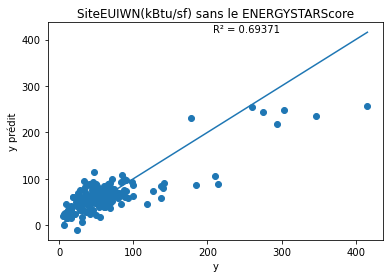

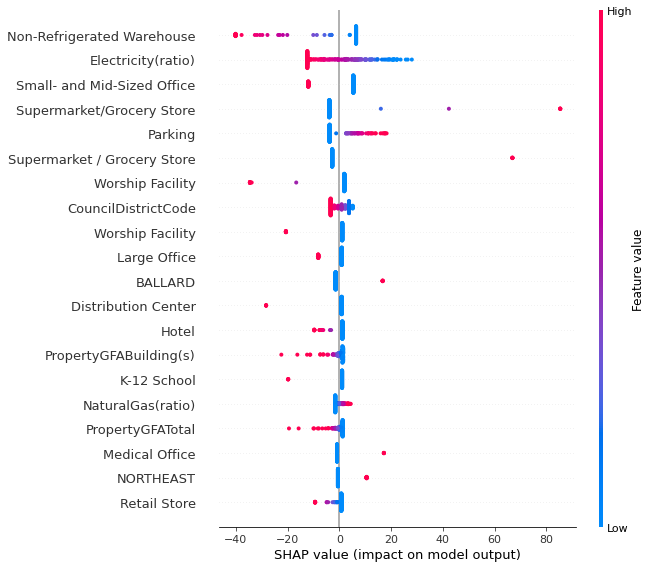

In [44]:
# Fit avec le train set
pipeline = make_pipeline(preprocessor, selected_model)
pipeline.fit(X_train, y_train)

# SHAP
lin_reg_explainer1 = shap.LinearExplainer(selected_model, preprocessor.transform(X_train))
        
# Predict
y_pred = pipeline.predict(X_test)

print(' R² = ', pipeline.score(X_test, y_test))

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.text((y_test.max()/2), y_test.max(), 'R² = %.5f' % (pipeline.score(X_test, y_test)))
plt.xlabel('y')
plt.ylabel('y prédit')
plt.title('SiteEUIWN(kBtu/sf) sans le ENERGYSTARScore')
plt.show()

plt.figure()
shap.summary_plot(lin_reg_explainer1.shap_values(preprocessor.transform(X_test)),
                  features = preprocessor.transform(X_test),
                # Récupérer les noms de variables après preprocess
                  feature_names = np.concatenate((preprocessor.transformers_[0][2], 
                                                preprocessor.transformers_[1][1][0].categories_[0], 
                                                 preprocessor.transformers_[1][1][0].categories_[1]), 
                                                 axis=None)
                 )